# Quantization 

## Quantization types

- Scalar quantization 
- Binary quantization 
- Product quantization

Scalar quantization is simply transforming the `float` to `int`. `~4x` space reductions

Binary quantization works by transforming `float` to `bool`. `~32x` space reduction.

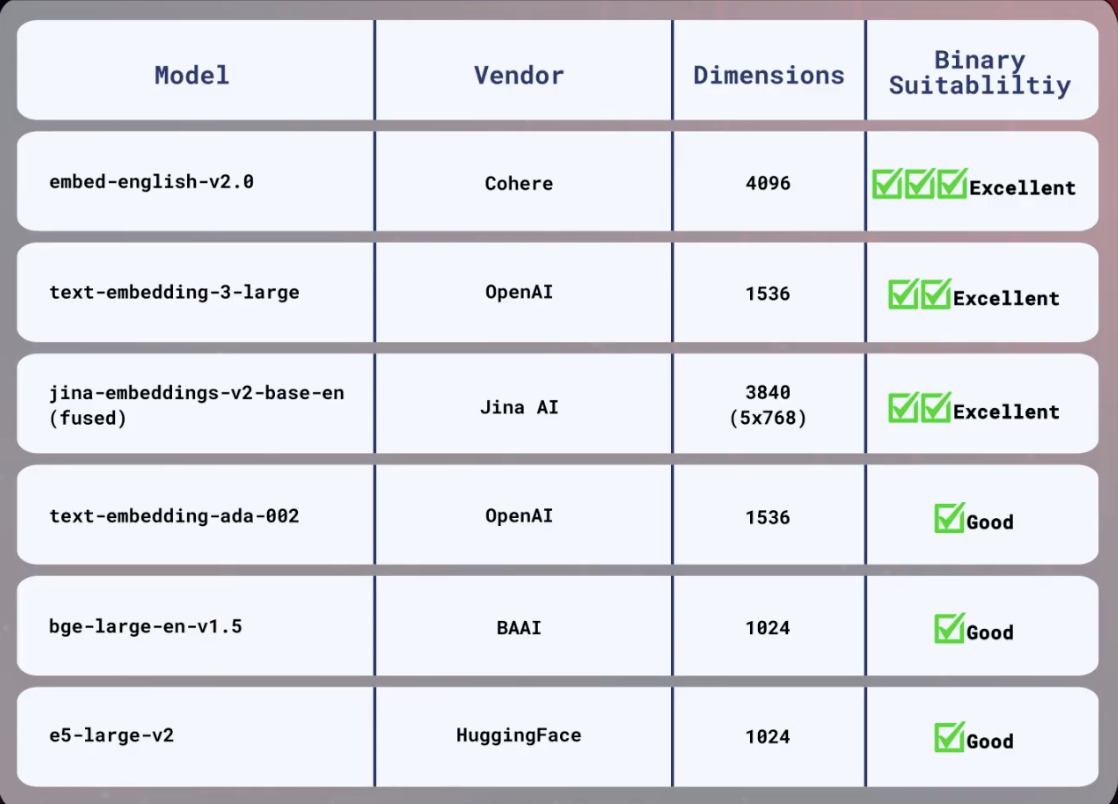

Product Quantization - not generally recommended

## Comparison between methods

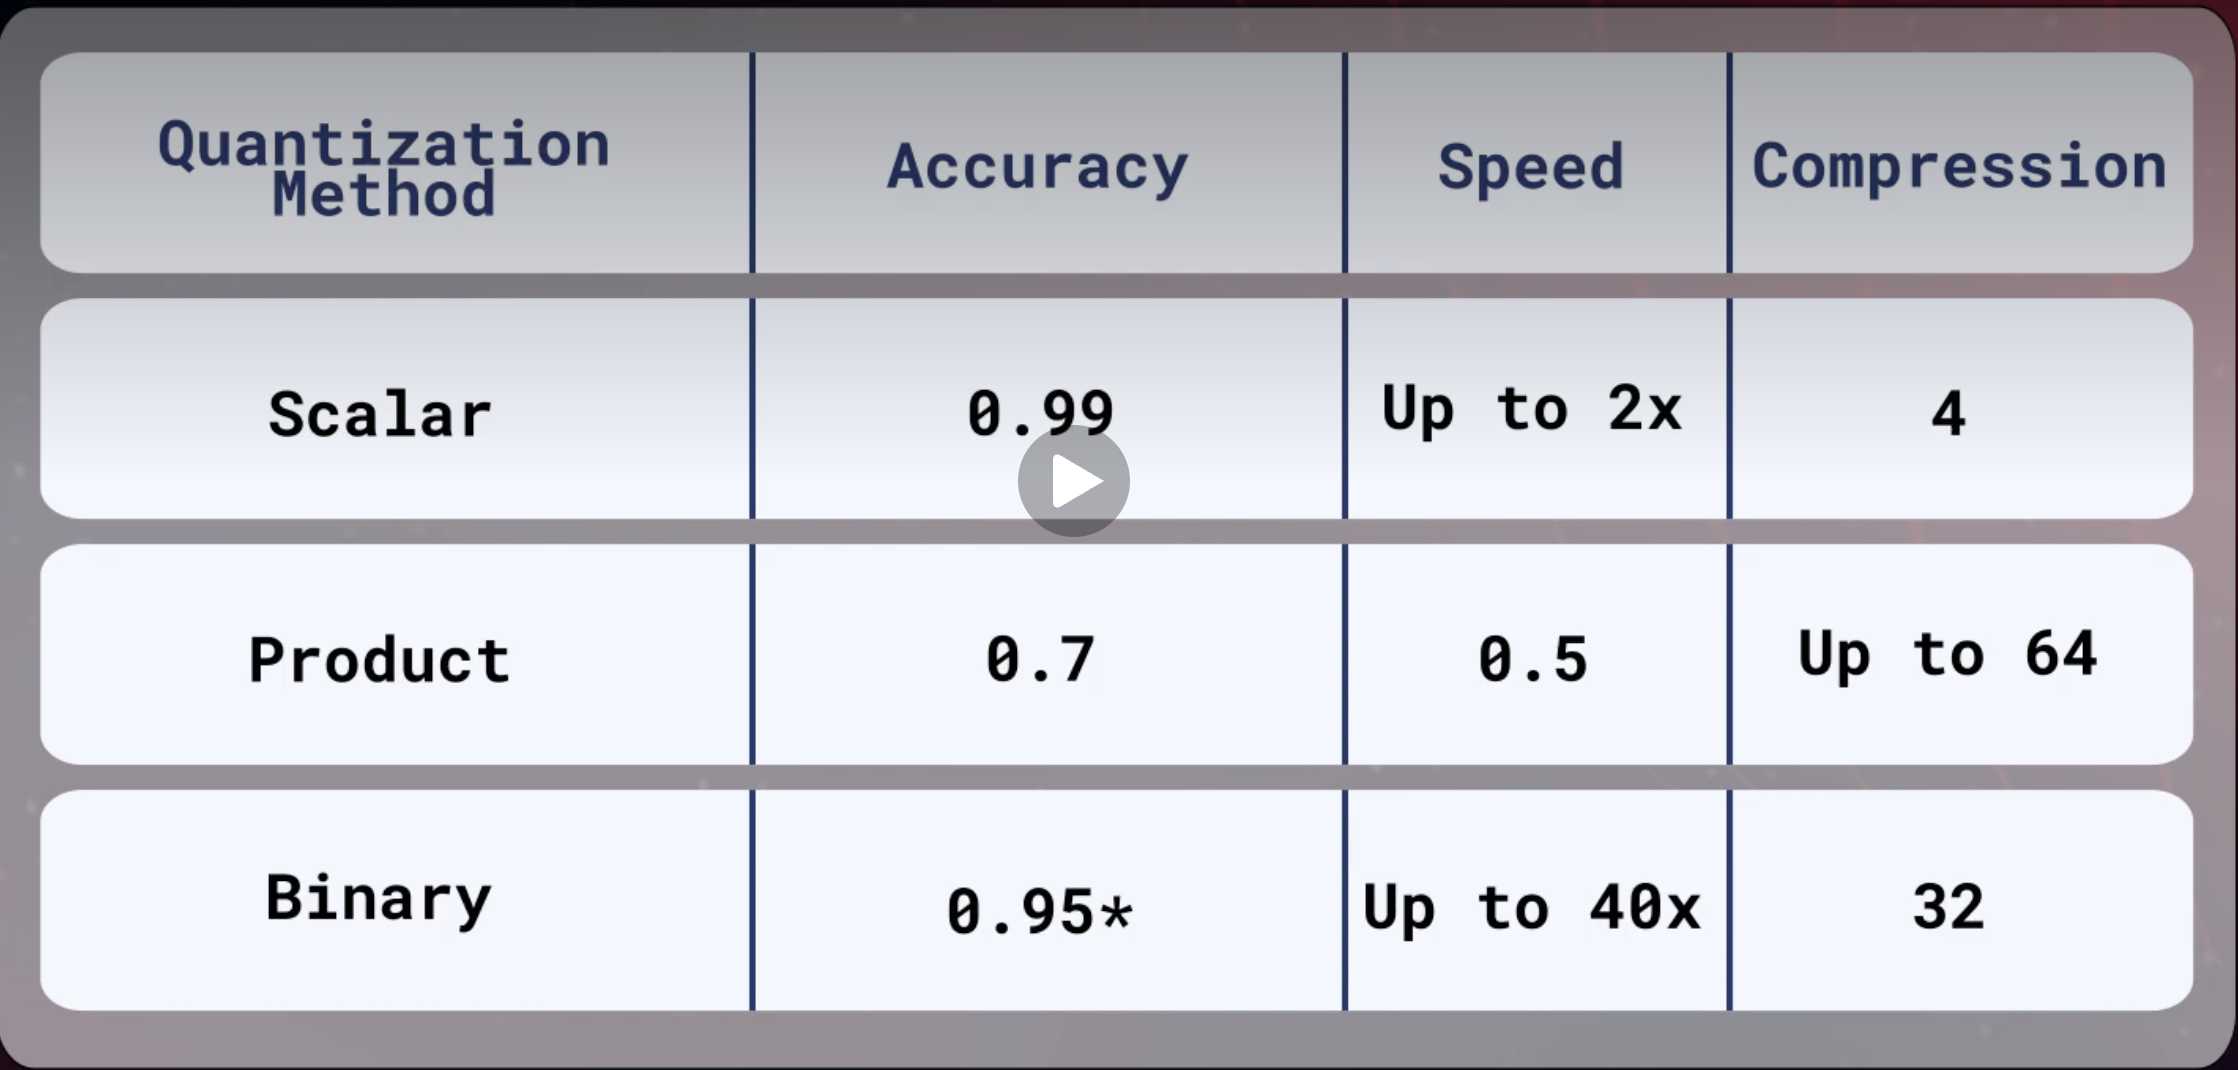

In [1]:
from day_four.dataset import wolt_food_ds

wolt_food_ds

/Users/andrei/projects/qdrant-essesials/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['id', 'cafe', 'description', 'image', 'image_file', 'name', 'vector'],
        num_rows: 1720611
    })
})

In [2]:
import os

from qdrant_client import QdrantClient

client = QdrantClient(
    url=os.getenv('QDRANT_URL'),
    api_key=os.getenv('QDRANT_CLIENT_ID')
)

In [48]:
global collection_name
collection_name = 'wolf-food-db'

In [4]:
client.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='midjourney'), CollectionDescription(name='sport-drug'), CollectionDescription(name='wolf-food-db')])

In [31]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("clip-ViT-B-32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9120.24it/s]


In [32]:
model

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'get_text_features', 'method_output_name': 'pooler_output'}, 'image': {'method': 'get_image_features', 'method_output_name': 'pooler_output'}}, 'module_output_name': 'sentence_embedding', 'architecture': 'CLIPModel'})
)

In [33]:
from time import time

import numpy as np


def measure_search_performance(
    collection_name: str,
    test_queries: list[str],
    label: str = 'Baseline'
):
    """
    Measure search performance accross queries
    """

    latencies: list[float] = []

    response = client.query_points(
        collection_name=collection_name, 
        query=model.encode(test_queries[0]).tolist(),
        limit=10
    )

    for query in test_queries:
        start_time = time()

        query_encoded = model.encode(query).tolist()

        response = client.query_points(
            collection_name,
            query=query_encoded,
            limit=10
        )

        latency = time() - start_time
        latencies.append(latency)
    
    avg_latency = np.mean(latencies)
    # 95% percentale of the performance - higher median
    p95_latency = np.percentile(latencies, 95)

    print(f"===Label of the benchmark: {label}===")
    print(f" Average latency: {avg_latency:2f}ms")
    print(f" P95 latency: {p95_latency:2f}ms")


    return { 'avg': avg_latency, 'p95': p95_latency }



### Populate the baseline

In [6]:
from qdrant_client.models import (
    Distance,
    HnswConfigDiff,
    VectorParams,
)

recreated = client.recreate_collection(
    collection_name,
    vectors_config=VectorParams(
        size=512,
        distance=Distance.COSINE,
        on_disk=True,
    ),
    hnsw_config=HnswConfigDiff(
        m=6,
        on_disk=False
    )
)


recreated

/var/folders/pq/gsx7ryn905s1bypf32zs4k980000gn/T/ipykernel_16609/1753427939.py:7: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  recreated = client.recreate_collection(


True

In [7]:
len(wolt_food_ds['train'])

1720611

In [8]:
selected_20 = wolt_food_ds['train'].select(range(20))

In [ ]:
import numpy as np

column_s = selected_20['vector']

np.frombuffer(list(column_s), dtype=np.float32)


[b'[-0.01112570520490408,0.06796321272850037,-0.012293401174247265,0.03143953159451485,0.05365539714694023,0.009010696783661842,0.030162816867232323,0.04258204251527786,0.06885802000761032,-0.001707581919617951,-0.01697002723813057,0.05179916322231293,-0.00316661037504673,0.016363877803087234,0.006129481829702854,-0.04416534677147865,0.05753525346517563,-0.018557941541075706,0.022047454491257668,-0.025152090936899185,-0.21384920179843903,0.0018526609055697918,0.001507932203821838,-0.04893197864294052,0.06619296967983246,0.025952333584427834,-0.030805906280875206,-0.012624726630747318,-0.021460119634866714,0.014542951248586178,-0.01128413900732994,0.02046910673379898,-0.021539190784096718,0.007524389307945967,0.054124247282743454,0.04023434594273567,-0.025198204442858696,0.024512186646461487,-0.02511986531317234,0.1709502637386322,-0.028594456613063812,-0.013135530985891819,0.013819494284689426,0.0309467576444149,-0.019303258508443832,-0.04648208245635033,0.048536788672208786,-0.0214618

In [10]:
wolt_food_ds['train'].select(range(20, len(wolt_food_ds['train'])))

Dataset({
    features: ['id', 'cafe', 'description', 'image', 'image_file', 'name', 'vector'],
    num_rows: 1720591
})

In [20]:
row = wolt_food_ds["train"][0]

print(type(row["vector"]))
print(len(row["vector"]))
print(row["vector"][:100])

<class 'bytes'>
10827
b'[-0.01112570520490408,0.06796321272850037,-0.012293401174247265,0.03143953159451485,0.05365539714694'


In [21]:
import json 

wolt_food_ready = wolt_food_ds['train'].map(
    lambda x: {
        "vector": json.loads(x["vector"].decode())
    }
)

Map: 100%|██████████| 1720611/1720611 [05:51<00:00, 4888.45 examples/s] 


In [22]:
row = wolt_food_ready[0]

print(type(row["vector"]))
print(len(row["vector"]))
print(row["vector"][:100])

<class 'list'>
512
[-0.01112570520490408, 0.06796321272850037, -0.012293401174247265, 0.03143953159451485, 0.05365539714694023, 0.009010696783661842, 0.030162816867232323, 0.04258204251527786, 0.06885802000761032, -0.001707581919617951, -0.01697002723813057, 0.05179916322231293, -0.00316661037504673, 0.016363877803087234, 0.006129481829702854, -0.04416534677147865, 0.05753525346517563, -0.018557941541075706, 0.022047454491257668, -0.025152090936899185, -0.21384920179843903, 0.0018526609055697918, 0.001507932203821838, -0.04893197864294052, 0.06619296967983246, 0.025952333584427834, -0.030805906280875206, -0.012624726630747318, -0.021460119634866714, 0.014542951248586178, -0.01128413900732994, 0.02046910673379898, -0.021539190784096718, 0.007524389307945967, 0.054124247282743454, 0.04023434594273567, -0.025198204442858696, 0.024512186646461487, -0.02511986531317234, 0.1709502637386322, -0.028594456613063812, -0.013135530985891819, 0.013819494284689426, 0.0309467576444149, -0.01930325850

In [25]:
from typing import cast

wolt_vector = wolt_food_ready['vector']

client.upload_collection(
    collection_name,
    vectors=wolt_vector,
    batch_size=256,
    parallel=4,
    payload=cast(list[dict], wolt_food_ready)
)

In [9]:
wolt_food_ds['train'][0]

{'id': 0,
 'cafe': b'{"name":"Sweet Spot","categories":["bakery","bakeries","breakfast","brunch","cafe","coffee-tea","dessert","healthy","smoothie","sweets","vegan","vegetarian"],"rating":8.8,"address":"Fjordgata 17B","menu_id":"621ca6ffaf57b97173edd98e","location":{"lat":63.4344428,"lon":10.4006097},"slug":"sweet-spot"}',
 'description': 'Proteinrik havregrøt med smak av banan og vanilje. Standar topping er: Kanel og sukring gold, banan, ferske jordbær, frossen blåbær eller frossen bringebær, og peanøttsaus.\n\n356 Kcal og 28 g protein',
 'image': 'https://wolt-menu-images-cdn.wolt.com/menu-images/621ca6ffaf57b97173edd98e/e8040fe4-9889-11ec-8f1f-32f843cc531c_havregr_t2.jpeg',
 'image_file': 'e8040fe4-9889-11ec-8f1f-32f843cc531c_havregr_t2.jpeg',
 'name': 'Banana Peanut havregrøt',
 'vector': b'[-0.01112570520490408,0.06796321272850037,-0.012293401174247265,0.03143953159451485,0.05365539714694023,0.009010696783661842,0.030162816867232323,0.04258204251527786,0.06885802000761032,-0.00170

In [28]:
client.get_collection(collection_name)

CollectionInfo(status=<CollectionStatus.YELLOW: 'yellow'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=315648, points_count=1720611, segments_count=5, config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=512, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=True, datatype=None, multivector_config=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=6, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimization_threads=None, prevent_unopti

In [76]:
search_queries = [
    # --- Visual appearance (CLIP's strongest suit) ---
    "crispy golden fried chicken with dark grill marks",
    "vibrant green salad with avocado and cherry tomatoes",
    "melted cheese pull on a burger",
    "glossy chocolate lava cake with powdered sugar",

    # --- Craving / mood-driven (casual user) ---
    "something warm and comforting for a rainy day",
    "light and healthy lunch",
    "late night guilty pleasure snack",
    "post-workout high protein meal",

    # --- Cuisine style ---
    "Japanese ramen with soft boiled egg and nori",
    "classic Neapolitan pizza with charred crust",
    "Middle Eastern mezze platter with hummus",
    "Korean bibimbap colorful rice bowl",

    # --- Occasion ---
    "birthday cake with candles",
    "brunch plate with eggs benedict",
    "sharable party platter",

    # --- Interesting CLIP edge cases (test semantic limits) ---
    "food that looks like a painting",        # abstract visual concept
    "meal under 500 calories",                # numeric — CLIP likely ignores it
    "anything but sushi",                     # negation — CLIP can't negate
]

In [77]:
baseline_metrics = measure_search_performance(
    collection_name, 
    search_queries, 
    "Baseline (No Quantization)"
)

===Label of the benchmark: Baseline (No Quantization)===
 Average latency: 0.224255ms
 P95 latency: 0.308590ms


In [78]:
from qdrant_client.models import (
    BinaryQuantization,
    BinaryQuantizationConfig,
    BinaryQuantizationEncoding,
    ScalarQuantization,
    ScalarQuantizationConfig,
    ScalarType,
)

quantization_config = {
    'scalar': {
        'config': ScalarQuantization(
            scalar=ScalarQuantizationConfig(
                type=ScalarType.INT8,
                quantile=0.99,
                always_ram=True
            )
        ),
        'expected_speedup': '2x',
        'expected_compression': '4x',
    },
    'binary': {
        'config': BinaryQuantization(
            binary=BinaryQuantizationConfig(
                encoding=BinaryQuantizationEncoding.ONE_BIT,
                always_ram=True
            )
        ),
        'expected_speedup': '40x',
        'expected_compression': '32x',
    },
    'binary_2bit': {
        'config': BinaryQuantization(
            binary=BinaryQuantizationConfig(
                encoding=BinaryQuantizationEncoding.TWO_BITS,
                always_ram=True
            )
        ),
        'expected_speedup': '20x',
        'expected_compression': '16x',
    }
}

In [ ]:

collection_names = []
for method_name, config_info in quantization_config.items():
    col_name = f'quantized_{method_name}_{collection_name}'

    client.create_collection(
        collection_name=col_name,
        vectors_config=VectorParams(
            size=512,
            distance=Distance.COSINE,
            on_disk=True
        ),
        quantization_config=config_info['config']
    )

    print(f'Creating {method_name} quantized collection: {col_name}')

    collection_names.append(col_name)

/var/folders/pq/gsx7ryn905s1bypf32zs4k980000gn/T/ipykernel_16609/2781138464.py:5: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


Creating scalar quantized collection: quantized_scalar_wolf-food-db
Creating binary quantized collection: quantized_binary_wolf-food-db
Creating binary_2bit quantized collection: quantized_binary_2bit_wolf-food-db


In [80]:
from tqdm import tqdm

for col_name in collection_names:
    print(f"=== Uploading for the collection: {col_name} now===")

    client.upload_collection(
        col_name,
        vectors=tqdm(wolt_vector),
        batch_size=256,
        parallel=4,
        payload=cast(list[dict], wolt_food_ready)
    )

=== Uploading for the collection: quantized_scalar_wolf-food-db now===


100%|██████████| 1720611/1720611 [06:00<00:00, 4774.96it/s]


=== Uploading for the collection: quantized_binary_wolf-food-db now===


100%|██████████| 1720611/1720611 [06:10<00:00, 4649.46it/s]


=== Uploading for the collection: quantized_binary_2bit_wolf-food-db now===


100%|██████████| 1720611/1720611 [06:17<00:00, 4557.09it/s]


In [101]:
queries = [
    "pizza",
    "sushi",
    "burger",
    "chocolate cake",
]

for q in queries:
    vec = model.encode(q).tolist()

    result = client.query_points(
        collection_name=collection_name,
        query=vec,
        limit=5,
    )

    print(q)
    print([(p.id, p.payload['id']) for p in result.points])
    print()

pizza
[('e7ccc586-c98b-46c0-97a1-2dea62a554c7', 698420), ('62e84d37-a2c1-4eb6-bdc3-533400957b60', 803560), ('50455a10-a772-4ccd-ba27-0744b4012420', 708482), ('8813c7e9-64be-445e-bdfb-a18e469a7d44', 2340501), ('3c5f9c2c-7560-48e3-bf47-aad6c1b2c6b6', 989424)]

sushi
[('17610d7a-f189-4551-bfb1-0fa0dae6c6c0', 1361158), ('2cc219f8-43d5-43cd-b52c-dd4c4aa8a533', 1665846), ('1fd90925-c757-464d-aa7f-589c1a89410f', 2230265), ('3241ffee-343f-49f1-94c3-276e400a2096', 1665844), ('ea7b24a2-4040-4e07-b35b-c4c027247c33', 2230263)]

burger
[('fe419f25-768e-4fb4-b526-14b46d6f60c6', 2483927), ('876c274d-4a37-4757-ad8d-299652b31ef8', 2445065), ('228edb18-9221-4ac0-81ab-bb47d0059a05', 223296), ('459b6059-75e9-4b13-a068-5143f3dcee40', 1194442), ('57803e90-be7e-41e0-bd1e-1bee53d3a1cd', 747655)]

chocolate cake
[('933ba8ab-b5a9-4fcd-91a1-03b8c96ae9e5', 2224136), ('9751e39a-4d0b-4856-a9ca-6a0a6a11039e', 821904), ('1489fb8d-0ae1-4a09-b2ed-5efb99fa0962', 1531778), ('de6dd188-beb5-4f03-99d9-bbdc671119e7', 851438)

In [82]:
from qdrant_client.models import QuantizationSearchParams, SearchParams


def benchmark(collection_name: str, test_queries: list[str], method_name: str):
    """
    Measured quantized search performance
    """

    # test without oversampling/rescoring 

    no_rescoring_metrics = measure_search_performance(
        collection_name, 
        test_queries,
        f'{method_name} (No rescoring)'
    )

    def search_with_rescoring(collection_name: str, query: str, oversampling_factor = 3.0):
        start_time = time()

        query_encoded = model.encode(query).tolist()

        response = client.query_points(
            collection_name=collection_name, 
            query=query_encoded,
            limit=10,
            search_params=SearchParams(
                quantization=QuantizationSearchParams(
                    rescore=True,
                    oversampling=oversampling_factor
                )
            )
        )

        return (time() - start_time) * 1000, response

    rescoring_latencies = []
    
    # measure with rescoring
    for query in test_queries:
        latency, response = search_with_rescoring(collection_name, query)
        rescoring_latencies.append(latency)

    avg_rescoring = np.mean(rescoring_latencies)
    p95_rescoring = np.percentile(rescoring_latencies, 95)


    print(f"{method_name} (With Rescoring):")
    print(f"  Average latency: {avg_rescoring:.2f}ms")
    print(f"  P95 latency: {p95_rescoring:.2f}ms")
    
    return {
        "no_rescoring": no_rescoring_metrics,
        "with_rescoring": {"avg": avg_rescoring, "p95": p95_rescoring}
    }


In [83]:
collection_name

'wolf-food-db'

In [84]:
# test methods 


quantization_results = {}

for method_name in quantization_config:
    col_name  = f'quantized_{method_name}_{collection_name}'
    quantization_results[method_name] = benchmark(
        col_name, search_queries, method_name
    )


===Label of the benchmark: scalar (No rescoring)===
 Average latency: 0.290753ms
 P95 latency: 0.585401ms
scalar (With Rescoring):
  Average latency: 49.23ms
  P95 latency: 97.67ms
===Label of the benchmark: binary (No rescoring)===
 Average latency: 0.122807ms
 P95 latency: 0.237557ms
binary (With Rescoring):
  Average latency: 52.85ms
  P95 latency: 89.55ms
===Label of the benchmark: binary_2bit (No rescoring)===
 Average latency: 0.122585ms
 P95 latency: 0.225089ms
binary_2bit (With Rescoring):
  Average latency: 62.36ms
  P95 latency: 156.46ms


In [117]:
def measure_accuracy_retension(original_collection: str, quantized_collection: str, test_queries: list[str], factors=[2, 3, 5, 8, 10]):
    """
    Compare search results between OG and quantized collections
    """
    results = {}

    for factor in factors: 
        accuracy_scores = []

        for query in test_queries:  
            # print(f"Measure query is {query} for the factor {factor}")
            # baseline
            query_vector = model.encode(query).tolist()
            baseline_results = client.query_points(
                collection_name=original_collection,
                query=query_vector,
                limit=10
            )

            baseline_ids = [point.payload['id'] for point in baseline_results.points if point.payload is not None]


            # quantized results + rescoring
            quantized_results = client.query_points(
                collection_name=quantized_collection,
                query=query_vector,
                limit=10,
                search_params=SearchParams(
                    quantization=QuantizationSearchParams(
                        rescore=True,
                        oversampling=factor,
                    )
                )
            )

            quantized_ids = [point.payload['id'] for point in quantized_results.points if point.payload is not None]

            # print("baseline:", baseline_ids[:10])
            # print("quantized:", quantized_ids[:10])

            # overlap 
            overlap = len(set(baseline_ids) & set(quantized_ids))
            accuracy = overlap / len(baseline_ids)

            accuracy_scores.append(accuracy)

            # check if baseline ids are in the quantized_collection
            # for id_ in baseline_ids[:5]:
            #     res = client.retrieve(
            #         collection_name=quantized_collection,
            #         ids=[id_]
            #     )
            #     print(id_, len(res))
        
        results[factor] = {
            'avg_accuracy': np.mean(accuracy_scores)
        }


    return results
    


In [118]:
client.get_collection(collection_name)

CollectionInfo(status=<CollectionStatus.GREY: 'grey'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=1603584, points_count=1720611, segments_count=4, config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=512, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=True, datatype=None, multivector_config=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=6, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimization_threads=None, prevent_unoptimiz

In [119]:
def tune_oversampling(collection_name: str, queries: list[str], factors=[2, 3, 5, 8, 10]):
    """
    Find optimal oversampling factor
    """

    results = {}

    for factor in factors:
        latencies = []

        for query in queries:
            start_time = time()

            query_vector = model.encode(query).tolist()

            response = client.query_points(
                collection_name=collection_name, 
                query=query_vector,
                limit=10,
                search_params=SearchParams(
                    quantization=QuantizationSearchParams(
                        rescore=True,
                        oversampling=factor
                    )
                )
            )

            latencies.append((time() - start_time) * 1000)

        results[factor] = {
            'avg_latency': np.mean(latencies),
            'p95_latency': np.percentile(latencies, 95)
        }

    return results

In [120]:
collection_name

'wolf-food-db'

In [121]:
best_method = 'binary_2bit' # choose best based of latencies

oversampling_factors = [2, 3, 5, 8, 10]

oversampling_results_latency = tune_oversampling(
    f'quantized_{best_method}_{collection_name}',
    search_queries,
    oversampling_factors
)

oversampling_results_accuracy = measure_accuracy_retension(
    collection_name,
    f'quantized_{best_method}_{collection_name}',
    search_queries,
    oversampling_factors
)


print("===Oversampling Factor Optimization===")


for factor in oversampling_factors:
    print(f" {factor}x:")
    print(f" {oversampling_results_latency[factor]['avg_latency']:.2f}ms")
    print(f" {oversampling_results_accuracy[factor]['avg_accuracy']:.6f}")


===Oversampling Factor Optimization===
 2x:
 31.21ms
 0.100000
 3x:
 28.61ms
 0.127778
 5x:
 29.90ms
 0.227778
 8x:
 29.60ms
 0.272222
 10x:
 30.32ms
 0.288889


In [124]:
best_method = 'scalar' # choose best based of latencies

oversampling_factors = [2, 3, 5, 8, 10]

oversampling_results_latency = tune_oversampling(
    f'quantized_{best_method}_{collection_name}',
    search_queries,
    oversampling_factors
)

oversampling_results_accuracy = measure_accuracy_retension(
    collection_name,
    f'quantized_{best_method}_{collection_name}',
    search_queries,
    oversampling_factors
)


print("===Oversampling Factor Optimization===")


for factor in oversampling_factors:
    print(f" {factor}x:")
    print(f" {oversampling_results_latency[factor]['avg_latency']:.2f}ms")
    print(f" {oversampling_results_accuracy[factor]['avg_accuracy']:.6f}")


===Oversampling Factor Optimization===
 2x:
 236.19ms
 0.577778
 3x:
 19.76ms
 0.577778
 5x:
 24.21ms
 0.577778
 8x:
 28.03ms
 0.577778
 10x:
 23.29ms
 0.577778


In [123]:
print("=" * 60)
print("QUANTIZATION PERFORMANCE ANALYSIS")
print("="*60)

print("\n Baseline Performance: ")
print(f" Average latency: {baseline_metrics['avg']:.2f}ms")
print(f" P95 latency: {baseline_metrics['p95']:.2f}ms")

print("\nQuantization results")

for method, results in quantization_results.items():
    no_rescoring = results['no_rescoring']
    with_rescoring = results['with_rescoring']

    speedup_no_rescoring = baseline_metrics['avg'] / no_rescoring['avg']
    speedup_with_rescoring = baseline_metrics['avg'] / with_rescoring['avg']

    print(f"\n{method.upper()}:")
    print(f"  Without rescoring: {no_rescoring['avg']:.2f}ms ({speedup_no_rescoring:.1f}x speedup)")
    print(f"  With rescoring: {with_rescoring['avg']:.2f}ms ({speedup_with_rescoring:.1f}x speedup)")

QUANTIZATION PERFORMANCE ANALYSIS

 Baseline Performance: 
 Average latency: 0.22ms
 P95 latency: 0.31ms

Quantization results

SCALAR:
  Without rescoring: 0.29ms (0.8x speedup)
  With rescoring: 49.23ms (0.0x speedup)

BINARY:
  Without rescoring: 0.12ms (1.8x speedup)
  With rescoring: 52.85ms (0.0x speedup)

BINARY_2BIT:
  Without rescoring: 0.12ms (1.8x speedup)
  With rescoring: 62.36ms (0.0x speedup)


# [Day 4] Quantization Performance Optimization

## High-Level Summary

* **Domain:** Vector similarity search optimization using quantized embeddings in Qdrant
* **Key Result:** Binary and Binary-2bit quantization achieved the fastest raw search latency (1.8× faster than baseline), while Integer/Scalar quantization preserved significantly more retrieval quality. Oversampling beyond 3× provided negligible additional benefit.

---

## Reproducibility

* **Collections:**

  * `day4_baseline_collection`
  * `day4_quantized_scalar`
  * `day4_quantized_binary`
  * `day4_quantized_binary_2bit`

* **Model:**

  * 512-dimensional embedding model

* **Dataset:**

  * ~1.7 million vectors

* **Baseline Collection Configuration:**

```python
VectorParams(
    size=512,
    distance=Distance.COSINE,
    on_disk=True,
)

HnswConfigDiff(
    m=6,
    on_disk=False
)
```

* **Search Method:**

  * HNSW ANN search
  * Quantized search with optional rescoring
  * Oversampling factors tested: 2×, 3×, 5×, 8×, 10×

---

## Results

### Baseline

| Metric          | Value   |
| --------------- | ------- |
| Average latency | 0.22 ms |
| P95 latency     | 0.31 ms |

### Quantized Search (No Rescoring)

| Method      | Avg Latency | Speedup |
| ----------- | ----------- | ------- |
| Scalar      | 0.29 ms     | 0.8×    |
| Binary      | 0.12 ms     | 1.8×    |
| Binary-2bit | 0.12 ms     | 1.8×    |

### Quantized Search (With Rescoring)

| Method      | Avg Latency |
| ----------- | ----------- |
| Scalar      | 49.23 ms    |
| Binary      | 52.85 ms    |
| Binary-2bit | 62.36 ms    |

### Oversampling Study

| Oversampling | Avg Latency | ID Overlap |
| ------------ | ----------- | ---------- |
| 2×           | 31.21 ms    | 10.0%      |
| 3×           | 28.61 ms    | 12.8%      |
| 5×           | 29.90 ms    | 22.8%      |
| 8×           | 29.60 ms    | 27.2%      |
| 10×          | 30.32 ms    | 28.9%      |

### Integer Quantization Experiment

Integer quantization significantly outperformed binary approaches in retrieval consistency.

| Oversampling | Avg Latency | ID Overlap |
| ------------ | ----------- | ---------- |
| 2×           | 236.19 ms*  | 57.8%      |
| 3×           | 19.76 ms    | 57.8%      |
| 5×           | 24.21 ms    | 57.8%      |
| 8×           | 28.03 ms    | 57.8%      |
| 10×          | 23.29 ms    | 57.8%      |

*First run likely affected by warmup or cache effects.

---

## Accuracy Retention

Accuracy was measured using exact ID overlap between baseline and quantized top-k results.

### Binary Quantization

* Best overlap: ~28.9%
* Significant divergence from baseline neighbors

### Integer Quantization

* Stable overlap: ~57.8%
* Considerably higher retrieval consistency

Important note: exact ID overlap is a strict metric. Many retrieved vectors are likely semantically equivalent despite different IDs, meaning actual search quality is likely higher than reported.

---

## Method Notes

### Scalar (INT8)

Compresses vectors using 8-bit representations while approximately preserving original vector geometry. Offers a balance between memory reduction and retrieval quality.

### Binary (1-bit / 2-bit)

Encodes vector dimensions as compact bit representations. Maximizes compression and search speed but introduces substantial information loss, reducing nearest-neighbor fidelity.

---

## Surprise

The most surprising result was that oversampling had almost no impact on integer quantization quality. Retrieval overlap remained constant (~57.8%) from 3× through 10× oversampling, suggesting that either:

1. The candidate set was already saturated,
2. The quantized index was returning nearly identical candidates regardless of oversampling,
3. The original HNSW configuration was already highly optimized and limiting potential gains.

Another unexpected finding was that the baseline collection was already extremely fast (~0.22 ms average latency), leaving little room for quantization-based acceleration.

---

## Key Takeaways

* Binary quantization provides the best raw latency improvement (1.8×).
* Integer quantization preserves substantially more retrieval quality.
* Rescoring removes nearly all latency advantages of quantization.
* Oversampling beyond 3× offers little practical benefit on this dataset.
* With only 1.7M vectors and a highly optimized HNSW configuration (m=6), quantization appears more valuable for memory reduction than for latency improvement.

---

## Next Step

Run a controlled benchmark comparing four retrieval configurations against exact-search ground truth (Recall@10 and NDCG@10):

- Original collection (current HNSW configuration) — baseline reference.
- Original collection without HNSW (exact=True) — establish true nearest-neighbor ground truth and measure the benefit of HNSW itself.
- Quantized collection with default HNSW configuration — measure quantization impact under current settings.
- Quantized collection with tuned HNSW parameters (e.g., varying m and ef) — determine whether retrieval loss is caused by quantization or by graph traversal quality.

This experiment will isolate the contributions of HNSW and quantization separately, reveal whether the current baseline is already near-optimal, and provide a more reliable quality metric than strict top-K ID overlap.